# Validación del dataset tabular para ML

Auditoría de los Parquet derivados del datacubo. Cada fila representa una celda activa de Galicia y una fecha con cobertura EGIF. Este notebook es de **solo lectura** y no descarga ni modifica datos.

In [1]:
from collections import Counter
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as pads
import seaborn as sns

plt.style.use('default')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white'})
sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
DATASET_DIR = ROOT / 'data/processed/tabular/egif'
assert DATASET_DIR.exists(), f'No se encuentra: {DATASET_DIR}'
parts = sorted(DATASET_DIR.glob('year=*/*.parquet'))
assert parts, 'Todavía no hay ficheros Parquet. Ejecuta o espera a que termine el workflow.'
print(f'Ruta: {DATASET_DIR}')
print(f'Partes encontradas: {len(parts)}')

Ruta: C:\Users\alfon\PycharmProjects\Sistema-deteccion-incendios\data\processed\tabular\egif
Partes encontradas: 5


## 1. Integridad, particiones y esquema

In [2]:
metadata_path = DATASET_DIR / 'metadata.json'
if not metadata_path.exists():
    raise RuntimeError('La exportación aún no ha terminado: falta metadata.json. Vuelve a ejecutar esta celda cuando finalice el workflow.')
metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
display(pd.Series(metadata, name='valor').to_frame())

# `year` ya es una columna int16 dentro de cada Parquet; se evita inferirla
# de nuevo a partir de la carpeta `year=...`, que PyArrow tiparía como int32.
dataset = pads.dataset(parts, format='parquet')
schema = pd.DataFrame({'columna': dataset.schema.names, 'tipo': [str(field.type) for field in dataset.schema]})
display(schema)
required = {'fecha', 'cell_id', 'target_ignicion', 'year'}
assert required.issubset(dataset.schema.names), required - set(dataset.schema.names)
assert not ({'target_ignicion', 'burned_area_ha', 'large_fire_500ha'} & set(metadata['predictor_columns']))
print('✓ Esquema correcto y variables de resultado excluidas de los predictores.')

,valor
row_definition,One active 1 km Galicia cell on one EGIF-cover...
target,target_ignicion (EGIF-MITECO)
outcome_columns_not_predictors,"[burned_area_ha, large_fire_500ha, target_igni..."
predictor_columns,"[agriculture, artificial, aspect_000_045_fract..."
partitioning,year=YYYY/dataset_YYYY.parquet
annual_files,"{'2019': 10804365, '2020': 10833966, '2021': 1..."
dropped_rows_incomplete_predictors,0
source_datacube,data/processed/datacube/galicia_1km.nc
time_contract,No temporal shift; meteorological accumulation...


,columna,tipo
0,y,int64
1,x,int64
2,fecha,timestamp[ns]
3,is_galicia,uint8
4,elevation_mean,float
...,...,...
58,target_ignicion,uint8
59,burned_area_ha,float
60,large_fire_500ha,uint8
61,number,int64


✓ Esquema correcto y variables de resultado excluidas de los predictores.


In [3]:
partitions = pd.DataFrame([
    {'año': path.parent.name.removeprefix('year='), 'archivo': path.name, 'MB': path.stat().st_size / 1e6}
    for path in parts
])
display(partitions.groupby('año').agg(partes=('archivo', 'count'), MB=('MB', 'sum')).round(1))
assert set(partitions['año']).issubset({'2019', '2020', '2021', '2022', '2023'})
print('✓ Particionado anual coherente.')

,partes,MB
año,,
2019,1,1348.3
2020,1,1363.5
2021,1,1353.4
2022,1,1355.4
2023,1,1221.1


✓ Particionado anual coherente.


## 2. Resumen temporal y del target (lectura por lotes)

In [4]:
# Esta celda recorre solo cuatro columnas y evita cargar el dataset completo en memoria.
monthly_rows = Counter()
monthly_positives = Counter()
total_rows = total_positive = invalid_target = 0
for batch in dataset.scanner(columns=['fecha', 'target_ignicion', 'year'], batch_size=250_000).to_batches():
    frame = batch.to_pandas()
    total_rows += len(frame)
    total_positive += int(frame['target_ignicion'].sum())
    invalid_target += int((~frame['target_ignicion'].isin([0, 1])).sum())
    period = pd.to_datetime(frame['fecha']).dt.to_period('M')
    grouped = frame.assign(period=period).groupby('period')['target_ignicion'].agg(['count', 'sum'])
    for period_key, row in grouped.iterrows():
        monthly_rows[str(period_key)] += int(row['count'])
        monthly_positives[str(period_key)] += int(row['sum'])

monthly_df = pd.DataFrame({'filas': monthly_rows, 'positivos': monthly_positives})
monthly_df.index = pd.PeriodIndex(monthly_df.index, freq='M')
monthly_df = monthly_df.sort_index()
monthly_df['tasa_ignición_pct'] = 100 * monthly_df['positivos'] / monthly_df['filas']
display(pd.DataFrame({'filas': [total_rows], 'positivos': [total_positive], 'tasa_positivos_pct': [100 * total_positive / total_rows]}))
assert invalid_target == 0
assert total_positive > 0
print('✓ Target binario, cobertura EGIF completa y positivos presentes.')

,filas,positivos,tasa_positivos_pct
0,53015391,6189,0.011674


✓ Target binario, cobertura EGIF completa y positivos presentes.


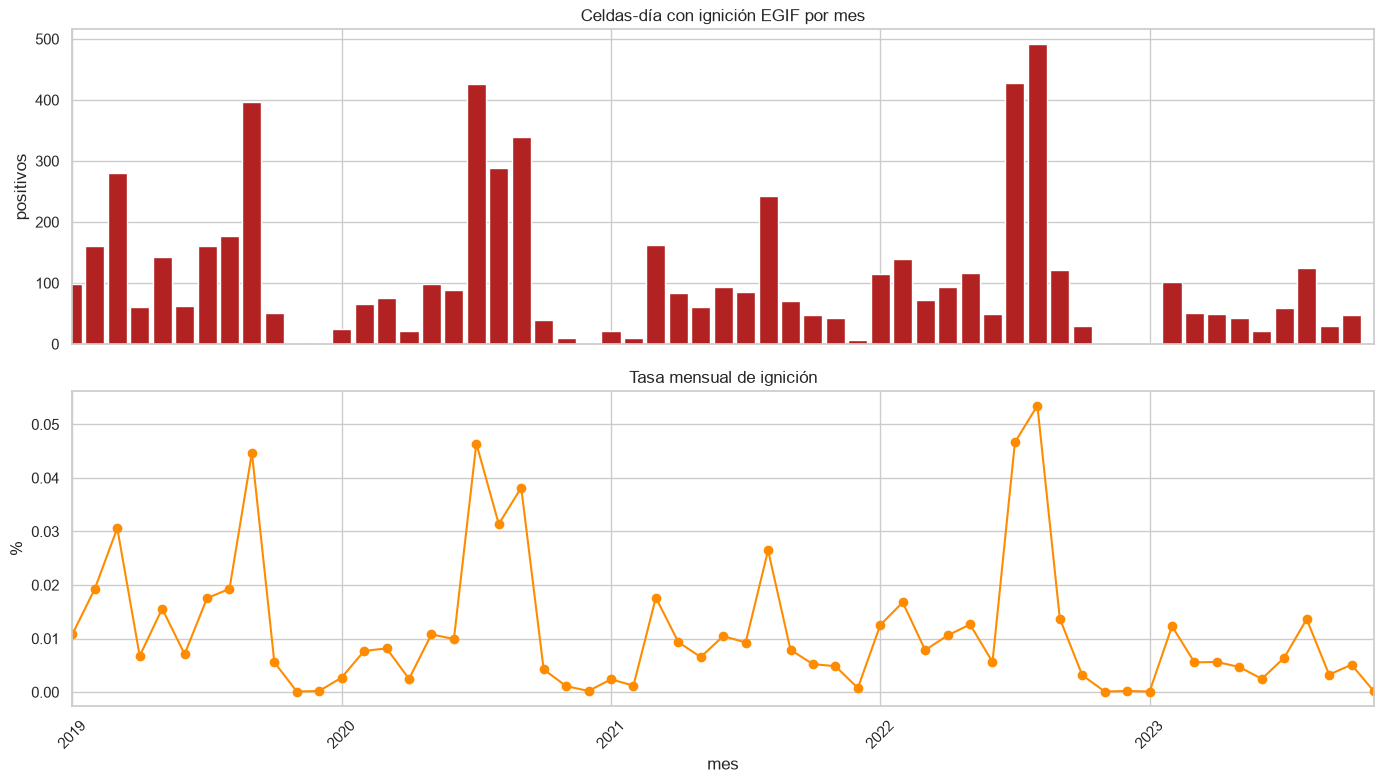

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, facecolor='white')
monthly_df['positivos'].plot(kind='bar', ax=axes[0], color='firebrick', width=0.85)
axes[0].set(title='Celdas-día con ignición EGIF por mes', ylabel='positivos')
monthly_df['tasa_ignición_pct'].plot(kind='line', marker='o', ax=axes[1], color='darkorange')
axes[1].set(title='Tasa mensual de ignición', ylabel='%', xlabel='mes')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 3. Validación meteorológica y valores ausentes

In [6]:
meteo_columns = [
    'temperature_max_12_18h', 'relative_humidity_min_12_18h', 'wind_speed_max_12_18h',
    'precipitation_sum', 'precipitation_sum_7d', 'precipitation_sum_30d', 'consecutive_dry_days',
]
available_meteo = [name for name in meteo_columns if name in dataset.schema.names]
assert len(available_meteo) == len(meteo_columns), set(meteo_columns) - set(available_meteo)
# Muestra aleatoria acotada: suficiente para gráficos sin llevar todo el dataset a memoria.
sample = dataset.head(300_000, columns=['fecha', 'target_ignicion', 'cell_id'] + available_meteo).to_pandas()
display(sample[available_meteo].describe(percentiles=[.01, .5, .99]).T)
missing = sample.isna().mean().sort_values(ascending=False).rename('fracción_na').to_frame()
display(missing.head(15))
max_missing = float(sample[available_meteo].isna().mean().max())
if max_missing > 0:
    print(f'Advertencia: {max_missing:.2%} de la muestra carece de todas las variables meteorológicas. Es un borde espacial fijo de la interpolación ERA5, no una ausencia temporal.')
assert max_missing < 0.05, 'La cobertura meteorológica insuficiente supera el 5 % de la muestra.'
sample_complete = sample.dropna(subset=available_meteo).copy()
assert sample_complete['relative_humidity_min_12_18h'].between(0, 100).all()
assert (sample_complete[['wind_speed_max_12_18h', 'precipitation_sum', 'consecutive_dry_days']] >= 0).all().all()
assert (sample_complete['precipitation_sum_30d'] + 1e-6 >= sample_complete['precipitation_sum_7d']).all()
print('✓ Rango físico y coherencia de acumulados meteorológicos correctos en las filas completas.')

,count,mean,std,min,1%,50%,99%,max
temperature_max_12_18h,300000.0,10.885346,1.632690,6.064301,6.732146,11.070182,13.886017,14.716295
relative_humidity_min_12_18h,300000.0,60.957012,9.863046,31.972137,38.096859,61.481741,81.707962,86.145325
wind_speed_max_12_18h,300000.0,7.375565,4.621212,1.414835,2.419080,5.859178,24.007017,31.991226
precipitation_sum,300000.0,0.004176,0.015356,0.000852,0.000852,0.001721,0.053221,0.312614
precipitation_sum_7d,300000.0,1.036657,1.961699,0.008577,0.008577,0.020537,9.457376,12.111549
precipitation_sum_30d,300000.0,132.272324,35.473698,53.186352,64.577551,124.336220,233.968121,303.968201
consecutive_dry_days,300000.0,10.365545,4.518847,3.000000,4.000000,10.000000,22.259953,24.000000


,fracción_na
fecha,0.0
target_ignicion,0.0
cell_id,0.0
temperature_max_12_18h,0.0
relative_humidity_min_12_18h,0.0
wind_speed_max_12_18h,0.0
precipitation_sum,0.0
precipitation_sum_7d,0.0
precipitation_sum_30d,0.0
consecutive_dry_days,0.0


✓ Rango físico y coherencia de acumulados meteorológicos correctos en las filas completas.


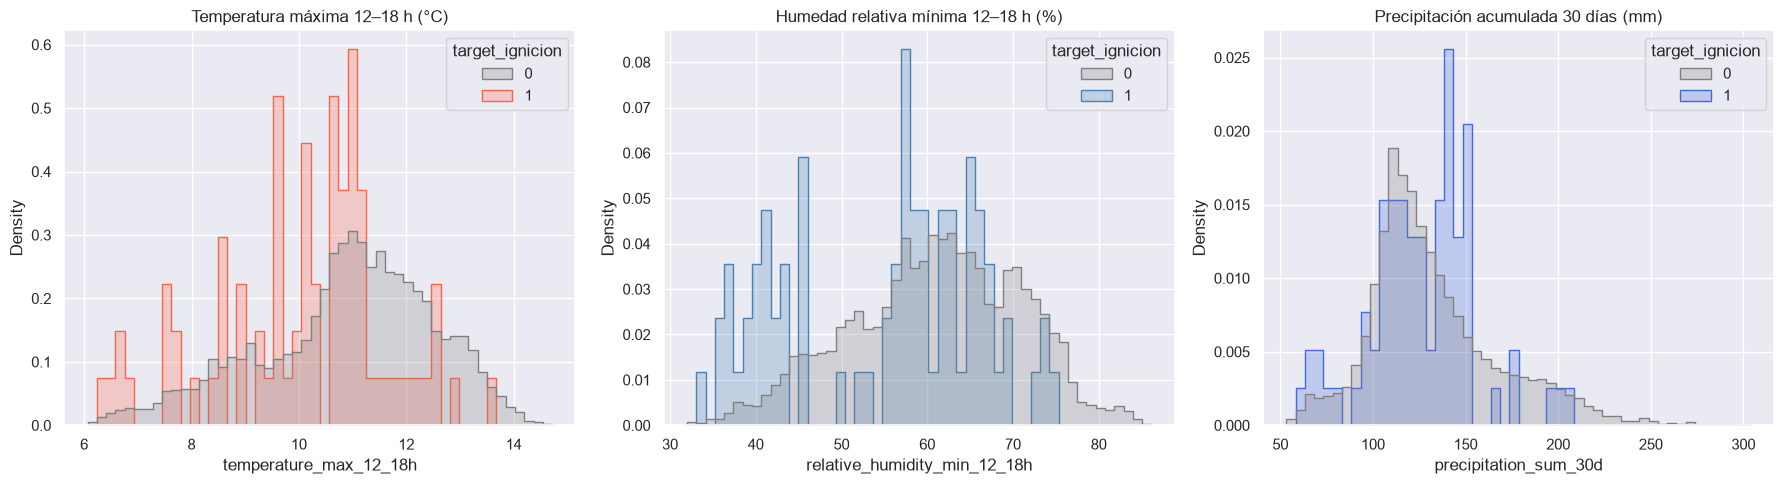

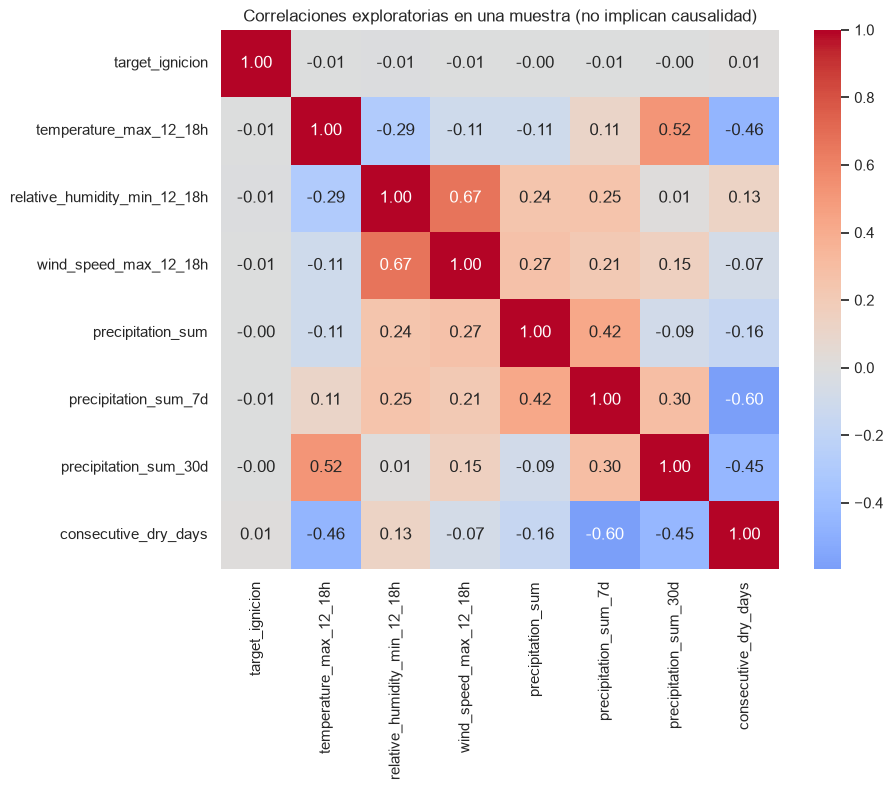

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')
plots = [
    ('temperature_max_12_18h', 'Temperatura máxima 12–18 h (°C)', 'tomato'),
    ('relative_humidity_min_12_18h', 'Humedad relativa mínima 12–18 h (%)', 'steelblue'),
    ('precipitation_sum_30d', 'Precipitación acumulada 30 días (mm)', 'royalblue'),
]
for ax, (column, title, color) in zip(axes, plots):
    sns.histplot(data=sample_complete, x=column, hue='target_ignicion', bins=50, stat='density', common_norm=False, element='step', ax=ax, palette={0: 'grey', 1: color})
    ax.set_title(title)
plt.tight_layout()
plt.show()

corr_cols = ['target_ignicion'] + available_meteo
plt.figure(figsize=(9, 7), facecolor='white')
sns.heatmap(sample_complete[corr_cols].corr(numeric_only=True), cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Correlaciones exploratorias en una muestra (no implican causalidad)')
plt.show()

## 4. Duplicados, separación de resultados y preparación para ML

In [8]:
sample_duplicates = int(sample.duplicated(['fecha', 'cell_id']).sum())
assert sample_duplicates == 0, 'Hay pares fecha-cell_id duplicados en la muestra.'
outcomes = set(metadata['outcome_columns_not_predictors'])
predictors = metadata['predictor_columns']
print(f'Predictores disponibles: {len(predictors)}')
print(f'Resultados/auditoría excluidos del entrenamiento: {sorted(outcomes)}')
print('✓ No hay duplicados en la muestra y el esquema separa predictores de resultados.')

print('Recomendación de validación ML: entrenar con años previos y reservar el tramo más reciente como test temporal; no usar particiones aleatorias.')

Predictores disponibles: 54
Resultados/auditoría excluidos del entrenamiento: ['burned_area_ha', 'large_fire_500ha', 'target_ignicion']
✓ No hay duplicados en la muestra y el esquema separa predictores de resultados.
Recomendación de validación ML: entrenar con años previos y reservar el tramo más reciente como test temporal; no usar particiones aleatorias.
